In [1]:
import os 
import torch 
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import random
import sys
import os

In [2]:
sys.path.append(os.path.abspath(os.path.join('..')))

In [3]:
from src.utils import set_seed

set_seed(5)

In [4]:
clases_indice = {'Windshield Fluid': 0, 'Engine': 1, 'Battery': 2, 'Engine Cover': 3, 'Air Filter': 4, 'Reservoir Cap': 5, 'Coolant Reservoir': 6}
indice_clases = {0:'Windshield Fluid', 1:'Engine', 2:'Battery', 3:'Engine Cover', 4:'Air Filter', 5:'Reservoir Cap', 6:'Coolant Reservoir',}

He estado pensando en la opción de preprocesar todo el conjunto de imágenes primero o procesar a demanda. He decidido la primera opción porque el conjunto de imágenes no es muy grande y hacer que el getitem abriese las imágenes cuando las necesitase aumentaba mucho el tiempo de entrenamiento. Actualmente estoy buscado soluciones para esto.

In [5]:
from src.utils import preprocesado_imagen

directorio = "../data/Toyota Corolla Dataset"
X = []
y = []
for carpeta in os.listdir(directorio):
    if carpeta != 'Dataset sample.png':
        ruta_carpeta = os.path.join(directorio, carpeta)
        for imagen in os.listdir(os.path.join(ruta_carpeta)):
            if not imagen.endswith(".Identifier"):
                ruta_completa = os.path.join(ruta_carpeta, imagen)
                image = preprocesado_imagen(ruta_completa)
                X.append(image)
                y.append(clases_indice[carpeta])

In [6]:
from src.dataset import ImagenDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
import collections

conteo = collections.Counter(y)
print("Distribución de clases:", dict(sorted(conteo.items())))

Distribución de clases: {0: 171, 1: 212, 2: 269, 3: 187, 4: 206, 5: 11, 6: 296}


La clase 5 reservoir cap solo tiene 11 imágenes por lo que está muy desbalanceada.

In [8]:
dataset_imagenes = ImagenDataset(X, y)

In [9]:
torch.save(dataset_imagenes, "../data/dataset_preprocesado.pt")

In [10]:
dataset_imagenes = torch.load("../data/dataset_preprocesado.pt", weights_only=False)

In [11]:
len_train = int(len(dataset_imagenes) * 0.8)
len_val = int(len(dataset_imagenes) * 0.1)
len_test = len(dataset_imagenes) - len_train - len_val

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset_imagenes,(len_train, len_val, len_test))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)

In [ ]:
from models.modelo import Modelo

modelo = Modelo().to(device)
lossfn = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo.parameters(), lr=0.0005)
num_epochs = 100
patience = 7

El Modelo se trata de una ResNet18 por tranferlearning. He probado varias opciones como hacer un red convoluciocional propia, pero ResNet18 tiene mejores resultados en test.

In [13]:
import time

def calculate_accuracy(model, data_, K=1):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in data_:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            topk = outputs.topk(K, dim=1)[1]
            correct_mask = topk.eq(targets.view(-1, 1).expand_as(topk))
            correct += correct_mask.sum().item()
            total += targets.size(0)

    accuracy = correct / total
    return accuracy

def train_model(model, optimizer, lossfn, train_loader, val_loader, patience, num_epochs):
    no_improvement = 0
    min_loss = float('inf')
    for epoch in range(num_epochs):
        start_time = time.time()

        total_train_loss = 0
        total_val_loss = 0

        model.train()
        for inputs, targets in train_loader: 
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = lossfn(outputs, targets)
            loss.backward()  
            optimizer.step()
            total_train_loss += loss.item()

        train_accuracy = calculate_accuracy(model, train_loader)

        model.eval()
        with torch.no_grad():
            for inputs, targets in val_loader:
                targets = torch.tensor(targets, dtype=torch.long)
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = lossfn(outputs, targets)
                total_val_loss += loss.item()

        val_accuracy = calculate_accuracy(model, val_loader)
        val_accuracy_3 = calculate_accuracy(model, val_loader, K=3)

        epoch_time = time.time() - start_time

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {total_train_loss/len(train_loader):.4f}, '
              f'Val Loss: {total_val_loss/len(val_loader):.4f}, '
              f'Train T1 Accuracy: {train_accuracy:.4f}, '
              f'Val T1 Accuracy: {val_accuracy:.4f}, '
              f'Val T3 Accuracy: {val_accuracy_3:.4f}, '
              f'Time: {epoch_time:.2f} sec')
        
        if total_val_loss < min_loss:
            min_loss = total_val_loss
            no_improvement = 0
        else:
            no_improvement += 1
        
        if no_improvement >= patience:
            print(f"No hay mejora por {patience} épocas. Parada Temprana!!")
            break

print(f"Entrenando CNN en {device}...")
train_model(modelo, optimizer, lossfn, train_loader, val_loader, patience, num_epochs)

Entrenando CNN en cuda...


/tmp/ipykernel_85098/2106564487.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.tensor(targets, dtype=torch.long)


Epoch [1/100], Train Loss: 1.7753, Val Loss: 1.6384, Train T1 Accuracy: 0.5643, Val T1 Accuracy: 0.5630, Val T3 Accuracy: 0.7037, Time: 3.49 sec
Epoch [2/100], Train Loss: 1.3370, Val Loss: 1.0983, Train T1 Accuracy: 0.7049, Val T1 Accuracy: 0.7481, Val T3 Accuracy: 0.9852, Time: 1.76 sec
Epoch [3/100], Train Loss: 0.8666, Val Loss: 0.6730, Train T1 Accuracy: 0.8779, Val T1 Accuracy: 0.9037, Val T3 Accuracy: 0.9926, Time: 1.83 sec
Epoch [4/100], Train Loss: 0.5795, Val Loss: 0.5242, Train T1 Accuracy: 0.8659, Val T1 Accuracy: 0.9037, Val T3 Accuracy: 0.9926, Time: 1.73 sec
Epoch [5/100], Train Loss: 0.4777, Val Loss: 0.3647, Train T1 Accuracy: 0.9019, Val T1 Accuracy: 0.9185, Val T3 Accuracy: 1.0000, Time: 1.79 sec
Epoch [6/100], Train Loss: 0.3745, Val Loss: 0.3131, Train T1 Accuracy: 0.9315, Val T1 Accuracy: 0.9111, Val T3 Accuracy: 1.0000, Time: 1.83 sec
Epoch [7/100], Train Loss: 0.3115, Val Loss: 0.3197, Train T1 Accuracy: 0.9389, Val T1 Accuracy: 0.9185, Val T3 Accuracy: 1.0000, 

In [14]:
test_accuracy = calculate_accuracy(modelo, test_loader)
print(f"Accuracy en cojunto de test {test_accuracy:.4f}")

Accuracy en cojunto de test 0.9632


In [15]:
ruta_modelo = "../models/modelo_corolla.pth"
torch.save(modelo.state_dict(), ruta_modelo)
print(f"Modelo guardado en {ruta_modelo}")

Modelo guardado en ../models/modelo_corolla.pth


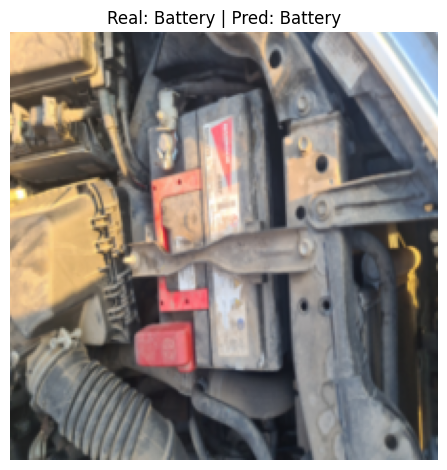

In [16]:
import matplotlib.pyplot as plt

indx = random.randint(0, len(test_dataset)-1)
imagen, etiqueta = test_dataset[indx]
imagen = imagen.to(device)
modelo.eval()
with torch.no_grad():
    output = modelo(imagen.unsqueeze(0))
imagen = imagen.to('cpu')
pred = output.argmax(1).item()
mean = torch.tensor([0.485, 0.456, 0.406]) 
std = torch.tensor([0.229, 0.224, 0.225]) 
imagen_n = imagen * std[:, None, None] + mean[:, None, None]
imagen_n = imagen_n.permute(1, 2, 0)
plt.imshow(imagen_n.squeeze())
plt.title(f"Real: {indice_clases[etiqueta]} | Pred: {indice_clases[pred]}")
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from lime import lime_image

explainer = lime_image.LimeImageExplainer()
def predict_fn(images):
    modelo.eval()
    batch = []

    for img in images:
        # img es numpy HWC en rango [0,1]
        img = torch.tensor(img).permute(2, 0, 1).float()

        # Normalizar igual que en tu dataset
        img = (img - mean[:, None, None]) / std[:, None, None]

        batch.append(img)

    batch = torch.stack(batch).to(device)

    with torch.no_grad():
        outputs = modelo(batch)
        probs = torch.softmax(outputs, dim=1)

    return probs.cpu().numpy()


In [18]:
imagen_n = imagen_n.cpu().numpy()
explanation = explainer.explain_instance(imagen_n, 
                                         predict_fn, 
                                         hide_color=0, 
                                         top_labels=1,
                                         num_samples=2000)

100%|██████████| 2000/2000 [00:04<00:00, 414.10it/s]


In [19]:
[indice_clases[i] for i in explanation.top_labels]

['Battery']

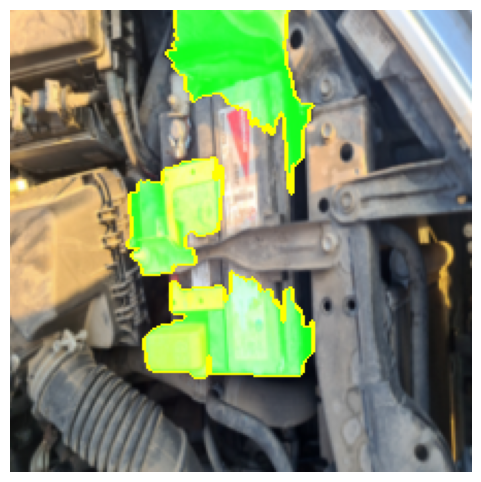

In [20]:
from skimage.segmentation import mark_boundaries

# Display the explanation using matplotlib
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], 
                                            positive_only=False, 
                                            num_features=5, 
                                            hide_rest=False)
# Asegurar rango correcto 
temp = temp.astype(float) 
temp = (temp - temp.min()) / (temp.max() - temp.min() + 1e-8) 
plt.figure(figsize=(6,6)) 
plt.imshow(mark_boundaries(temp, mask)) 
plt.axis('off') 
plt.show()

He añadido una explicación lime para doder observar que partes de la imagen son más importantes para que el modelo decida su predicción.

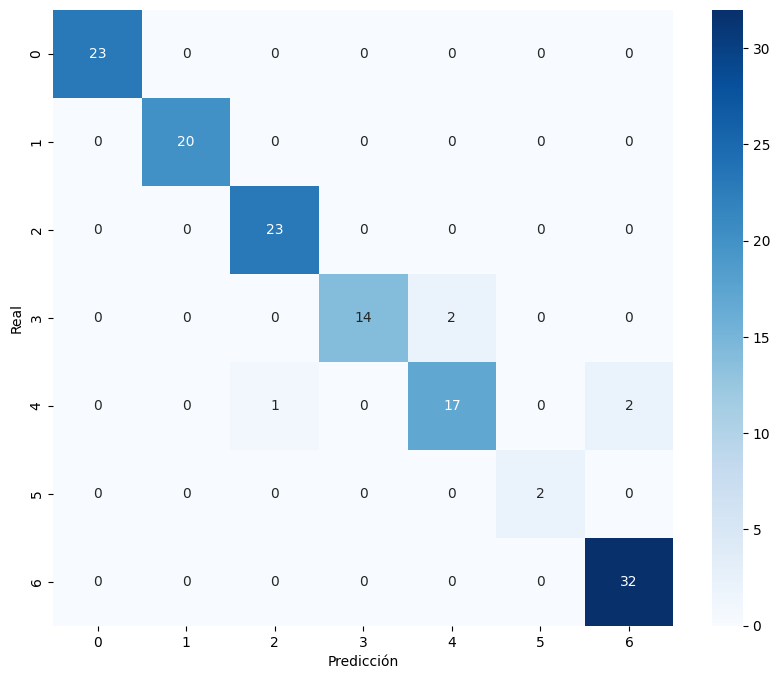

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, loader):
    y_true = []
    y_pred = []
    model.eval()
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(targets.numpy())
            y_pred.extend(preds.cpu().numpy())
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

plot_confusion_matrix(modelo, test_loader)

Tambien he añadido una matriz de confusión para visualizar que clases falla. Podemos ver que aunque la clase 5 este desbalanceada ha podido acertar los dos ejemplos que habían en el conjunto de test

Para visualizar los datos he elegido un autoencoder variacional ya que se tratan de datos de gran dimensionalidad. Para entrenar el VAE es necesario volver a cargar y procesar las imagenes pero esta vez sin normalizar.

In [22]:
from src.utils import preprocesado_imagenVAE

directorio = "../data/Toyota Corolla Dataset"
X = []
y = []
for carpeta in os.listdir(directorio):
    if carpeta != 'Dataset sample.png':
        ruta_carpeta = os.path.join(directorio, carpeta)
        for imagen in os.listdir(os.path.join(ruta_carpeta)):
            if not imagen.endswith(".Identifier"):
                ruta_completa = os.path.join(ruta_carpeta, imagen)
                image = preprocesado_imagenVAE(ruta_completa)
                X.append(image)
                y.append(clases_indice[carpeta])

dataset_imagenes = ImagenDataset(X, y)
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset_imagenes,(len_train, len_val, len_test))



train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)
imagenes_loader = DataLoader(dataset_imagenes, batch_size=64, shuffle=True, num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)

In [23]:
from models.modelo import VAE

MSE_loss = nn.MSELoss(reduction='mean')

modelo = VAE().to(device)
optimizer = optim.Adam(modelo.parameters(), lr=0.001)
num_epochs = 300

In [24]:
def trainVAE(modelo, optimizer, MSE_loss, train_loader, val_loader, num_epochs):

    for epoch in range(num_epochs):

        # ---------------------- ENTRENAMIENTO ----------------------
        modelo.train()
        train_loss = 0

        kl_weight = min(1.0, epoch / 200)

        for img, _ in train_loader:
            img = img.to(device)

            recon, mu, logvar = modelo(img)
            kul = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())) / img.size(0)
            mse = MSE_loss(recon, img)
            loss = (0.000000001 * kul * kl_weight) + mse  #Reduzco la importacia de la kl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ---------------------- VALIDACIÓN ----------------------
        modelo.eval()
        val_loss = 0

        with torch.no_grad():
            for img, _ in val_loader:
                img = img.to(device)

                recon, mu, logvar = modelo(img)
                kul = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())) / img.size(0)
                mse = MSE_loss(recon, img)
                loss = (0.000000001 * kul * kl_weight) + mse

                val_loss += loss.item()

        val_loss /= len(val_loader)

        print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

        # ---------------------- VISUALIZACIÓN ----------------------
        # He decidido quitar la visualización.
        """
        val_img, _ = next(iter(val_loader))
        val_img = val_img.to(device)

        with torch.no_grad():
            val_output, _, _ = modelo(val_img)
        
        
        plt.figure(figsize=(9, 3))

        # Original
        plt.subplot(1, 2, 1)
        plt.title("Imagen Original")
        plt.imshow(val_img[0].cpu().permute(1, 2, 0))
        plt.axis('off')

        # Reconstruida
        plt.subplot(1, 2, 2)
        plt.title("Reconstrucción")
        plt.imshow(val_output[0].cpu().permute(1, 2, 0))
        plt.axis('off')

        plt.show()
        """

trainVAE(modelo, optimizer, MSE_loss, train_loader, val_loader, num_epochs)

Epoch [1/300]  Train Loss: 0.0572  Val Loss: 0.0548
Epoch [2/300]  Train Loss: 0.0548  Val Loss: 0.0544
Epoch [3/300]  Train Loss: 0.0543  Val Loss: 0.0542
Epoch [4/300]  Train Loss: 0.0538  Val Loss: 0.0539
Epoch [5/300]  Train Loss: 0.0534  Val Loss: 0.0541
Epoch [6/300]  Train Loss: 0.0535  Val Loss: 0.0539
Epoch [7/300]  Train Loss: 0.0532  Val Loss: 0.0535
Epoch [8/300]  Train Loss: 0.0528  Val Loss: 0.0534
Epoch [9/300]  Train Loss: 0.0528  Val Loss: 0.0538
Epoch [10/300]  Train Loss: 0.0527  Val Loss: 0.0545
Epoch [11/300]  Train Loss: 0.0528  Val Loss: 0.0535
Epoch [12/300]  Train Loss: 0.0527  Val Loss: 0.0534
Epoch [13/300]  Train Loss: 0.0524  Val Loss: 0.0519
Epoch [14/300]  Train Loss: 0.0491  Val Loss: 0.0474
Epoch [15/300]  Train Loss: 0.0467  Val Loss: 0.0455
Epoch [16/300]  Train Loss: 0.0454  Val Loss: 0.0440
Epoch [17/300]  Train Loss: 0.0444  Val Loss: 0.0432
Epoch [18/300]  Train Loss: 0.0437  Val Loss: 0.0421
Epoch [19/300]  Train Loss: 0.0428  Val Loss: 0.0410
Ep

In [25]:
modelo.eval()

latents = []
labels = []

with torch.no_grad():
    for imgs, lbls in imagenes_loader:
        imgs = imgs.to(device)
        _, mu, _ = modelo(imgs)
        
        latents.append(mu.cpu())
        labels.append(lbls)

latents = torch.cat(latents, dim=0).numpy()
labels = torch.cat(labels, dim=0).numpy()


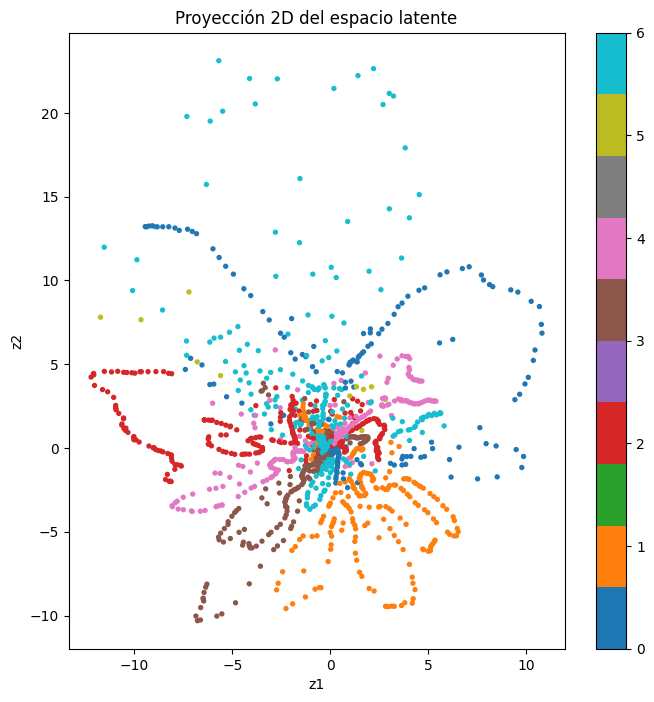

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(latents[:, 0], latents[:, 1], c=labels, cmap='tab10', s=8)
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Proyección 2D del espacio latente")
plt.colorbar()
plt.show()

A pesar de que no podemos ver clusteres bien definidos de cada clase, podemos observar otras cosas muy interesantes. Los puntos se centran en (0,0) y tiene forma de distribución normal, por lo que aunque he limitado la importancia de la kl_loss esta sigue siendo bastante importante. Los puntos no están perfectamente separados por clases, pero si nos fijamos hay clases que siguen un patron de pétalos de flor. Si nos fijamos podemos ver un pétalo naranja abajo a la derecha y otro rojo a la izquierda bastante bien definidos. Esto indica que la separación de clases aunque no perfecta es bastante buena.